In [4]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as pyplot

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [7]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [9]:
df.isnull().mean()         # approx 5% data missing in 'Fare' column and 19.8% missing data on 'Age' column

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


<h3 style='color:blue'>Train-test split </h3>

In [14]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
X_train.shape, X_test.shape

((668, 3), (223, 3))

In [15]:
# Missing values present in train data 
X_train.isnull().mean()

Age       0.199102
Fare      0.055389
Family    0.000000
dtype: float64

In [16]:
mean_age = df['Age'].mean() 
median_age = df['Age'].median() 

mean_fare = df['Fare'].mean() 
median_fare = df['Fare'].median() 

<h2 style='color:brown'>Using Pandas</h2>

In [19]:
# creating 4 different columns in which missing values has been filled by mean and median to check the effeciency. 
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train["Age"].fillna(median_age)

X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)
X_train['Fare_median'] = X_train["Fare"].fillna(median_fare)

In [20]:
X_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
504,16.0,86.5000,0,16.000000,16.0,86.5000,86.5000
599,49.0,56.9292,1,49.000000,49.0,56.9292,56.9292
828,NaN,7.7500,0,29.699118,28.0,7.7500,7.7500
91,20.0,7.8542,0,20.000000,20.0,7.8542,7.8542
383,35.0,52.0000,1,35.000000,35.0,52.0000,52.0000


In [27]:
# variance - square of the distance of the point from the mean.
print("Original Age variable Variance :", X_train['Age'].var())
print("Age Variance after Mean Imutation:", X_train['Age_mean'].var())
print("Age Variance after Median Imutation:", X_train['Age_median'].var(), '\n')    
# Age has around 20% missing values, so significant variance skrinkage can be observed. 

print("Original Fare variable Variance :", X_train['Fare'].var())
print("Fare Variance after Mean Imutation:", X_train['Fare_mean'].var())
print("Fare Variance after Median Imutation:", X_train['Fare_median'].var())

# After applying mean or median imputation, the variance of the column 'shrinks',
# you have to observe that the variance should not decrease drastically.

Original Age variable Variance : 209.90193932584322
Age Variance after Mean Imutation: 168.05387414764286
Age Variance after Median Imutation: 168.62394430958153 

Original Fare variable Variance : 2625.614945269419
Fare Variance after Mean Imutation: 2479.9663668610024
Fare Variance after Median Imutation: 2496.7384730103427


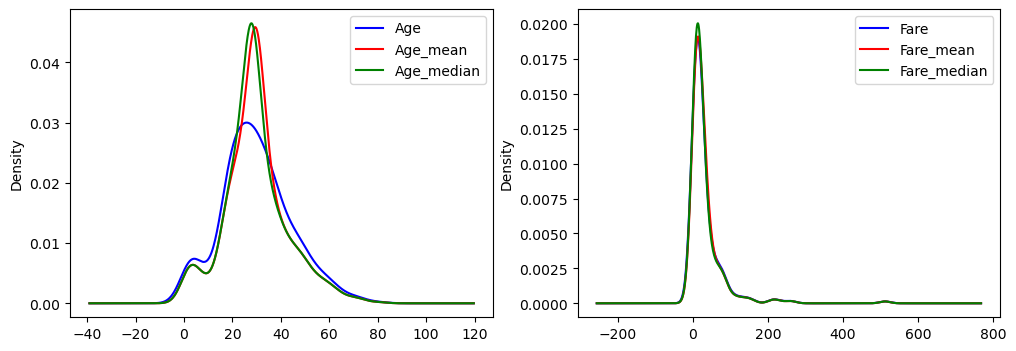

In [38]:
# Observe changes in the distribution of respective columns.

pyplot.figure(figsize=(12, 4))
pyplot.subplot(121)         # Age column
X_train['Age'].plot(kind='kde', color='blue', label='Age')                    # # original variable distribution
X_train['Age_mean'].plot(kind='kde', color='red', label='Age_mean')           # # variable imputed with the mean
X_train['Age_median'].plot(kind='kde', color='green', label='Age_median')     # # variable imputed with the median
pyplot.legend()   # to show the labels in the kde plot

pyplot.subplot(122)         # Fare column
X_train['Fare'].plot(kind='kde', color='blue', label='Fare')
X_train['Fare_mean'].plot(kind='kde', color='red', label='Fare_mean')
X_train['Fare_median'].plot(kind='kde', color='green', label='Fare_median')
pyplot.legend()   

pyplot.show()

# in Fare column, we can observe after applying the Mean or Median imputation, distribution remains almost same,
# so in such cases we can apply such imputation.

<h3 style='color:blue'>Checking Correlation & Covariance</h3>

In [42]:
X_train.corr()        # |ranges from -1 to 1.

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.109989,-0.297463,1.000000,1.000000,0.107291,0.106286
Fare,0.109989,1.000000,0.188900,0.105078,0.109396,1.000000,1.000000
Family,-0.297463,0.188900,1.000000,-0.234837,-0.234412,0.186644,0.187694
Age_mean,1.000000,0.105078,-0.234837,1.000000,0.998632,0.102575,0.101657
Age_median,1.000000,0.109396,-0.234412,0.998632,1.000000,0.106785,0.105759
Fare_mean,0.107291,1.000000,0.186644,0.102575,0.106785,1.000000,0.996660
Fare_median,0.106286,1.000000,0.187694,0.101657,0.105759,0.996660,1.000000


In [43]:
X_train.cov()        # no range limit

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,209.901939,87.427119,-6.406798,209.901939,209.901939,82.293840,81.839867
Fare,87.427119,2625.614945,16.579320,70.110165,73.112163,2625.614945,2625.614945
Family,-6.406798,16.579320,2.838689,-5.129207,-5.128585,15.660148,15.801411
Age_mean,209.901939,70.110165,-5.129207,168.053874,168.108383,66.219627,65.848839
Age_median,209.901939,73.112163,-5.128585,168.108383,168.623944,69.054869,68.622018
Fare_mean,82.293840,2625.614945,15.660148,66.219627,69.054869,2479.966367,2480.027796
Fare_median,81.839867,2625.614945,15.801411,65.848839,68.622018,2480.027796,2496.738473


<h3 style='color:blue'>Box-Plot to check for Outliers</h3>

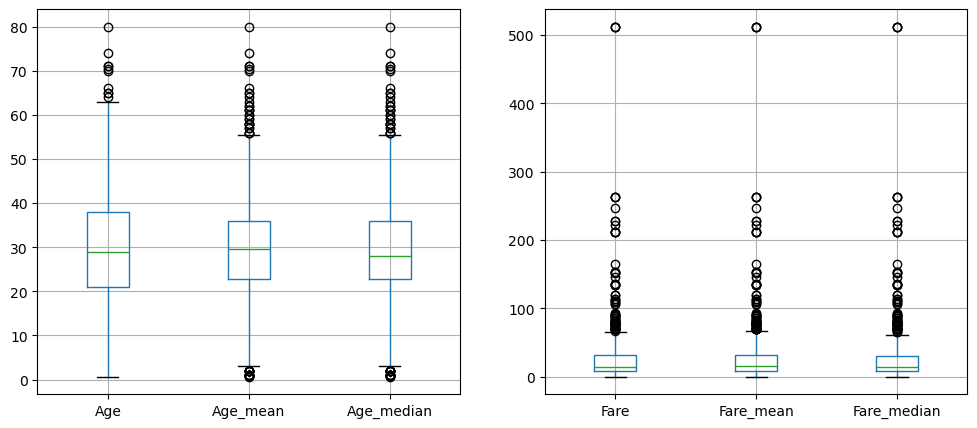

In [50]:
pyplot.figure(figsize=(12,5))
pyplot.subplot(121)
X_train[['Age','Age_mean','Age_median']].boxplot()         # IQR shrinks, more outliers appeared in mean/median imputation. 

pyplot.subplot(122)
X_train[['Fare','Fare_mean','Fare_median']].boxplot()      # no major change in outliers observed.
pyplot.show()
# IQR - Inter Quatile Range for mean and median shrinks, because of which we will observe more outliers as compared to original data.  

<h3 style='color:blue'>Observation</h3>

In [51]:
# We can use Mean-Median Imputation for 'Fare' column as we didn't get any red flags,
# whereas for 'Age' column we find that covariance, correlation values changes, outliers appears, data distribution changes,
# this red flags shows that this imputation technique is not appropriate for 'Age' column.

<h2 style='color:brown'> Using sklearn</h2>

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0) 
X_train.shape, X_test.shape

((668, 3), (223, 3))

In [81]:
imputer1 = SimpleImputer(strategy='mean')       # for 'Fare' column
imputer2 = SimpleImputer(strategy='median')     # for 'Age' column

In [82]:
tnf = ColumnTransformer(transformers=[
                            ('tnf_age', imputer2, ['Age']),
                            ('tnf_fare', imputer1, ['Fare']),
                        ], 
                        remainder='passthrough'
)

In [83]:
X_train = tnf.fit_transform(X_train)
X_test = tnf.transform(X_test)          # for transforming test data, we always use the train mean and median.

In [84]:
X_train

array([[28.    ,  7.8958,  0.    ],
       [17.    ,  7.925 ,  6.    ],
       [30.    , 16.1   ,  1.    ],
       ...,
       [29.    ,  7.7333,  0.    ],
       [36.    , 17.4   ,  1.    ],
       [60.    , 39.    ,  2.    ]])

In [85]:
tnf.named_transformers_

{'tnf_age': SimpleImputer(strategy='median'),
 'tnf_fare': SimpleImputer(),
 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                     feature_names_out='one-to-one')}

In [86]:
tnf.named_transformers_['tnf_age'].statistics_    # median

array([29.])

In [87]:
tnf.named_transformers_['tnf_fare'].statistics_    # mean

array([32.34510634])